# Smart-Kage master behavioural analysis

This notebook uses the master CSV files that already contain all age cohorts and genotype information.

Analyses included:
- T-maze performance
- T-maze number of trials
- T-maze side bias
- Average daily velocity

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import combinations

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## Figure style and constants

In [3]:
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.grid": False,
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "savefig.transparent": True,
    "savefig.bbox": "tight",
})

FIG_W = 6
FIG_H = 5
WIDE_W = 18
WIDE_H = 5

AGE_ORDER = ["6m", "12m", "24m"]
GENO_ORDER = ["WT", "NLGF"]

GENO_COLORS = {
    "WT": "#34C6D3",          # teal
    "NLGF": "#F062B8",        # pink
    "APP1-em1BDS": "#FF8C00", # orange
    "NLF": "#9B5DE5",         # purple
}


def format_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.tick_params(axis="both", direction="in", width=1.2, length=5, pad=6)
    ax.set_facecolor("white")
    return ax


def sem(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) <= 1:
        return np.nan
    return x.std(ddof=1) / np.sqrt(len(x))

## Load uploaded master CSV files

These files already contain all cohorts together, so this notebook does **not** search the original cohort folders.

In [5]:
DATA_DIR = Path("/Volumes/Aimi_SmrtKg/behaviour")

FILES = {
    "velocity": DATA_DIR / "velocity.csv",
    "nor_exploration": DATA_DIR / "NOR overall object exploration.csv",
    "nor_lr_bias": DATA_DIR / "NOR L-R bias.csv",
    "nor_di": DATA_DIR / "NOR disc index.csv",
    "tmaze_trials": DATA_DIR / "T-maze n trials.csv",
    "tmaze_side_bias": DATA_DIR / "T-maze side bias.csv",
    "tmaze_performance": DATA_DIR / "T-maze performance.csv",
    "activity_profile": DATA_DIR / "activity_profile.csv",
}

for name, path in FILES.items():
    print(name, path.exists(), path.name)

velocity True velocity.csv
nor_exploration True NOR overall object exploration.csv
nor_lr_bias True NOR L-R bias.csv
nor_di True NOR disc index.csv
tmaze_trials True T-maze n trials.csv
tmaze_side_bias True T-maze side bias.csv
tmaze_performance True T-maze performance.csv
activity_profile True activity_profile.csv


## Cleaning helpers

Genotype names are standardised here. 

In [6]:
def clean_age(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace("months", "m").replace("month", "m")
    if s in ["6", "6.0", "6m"]:
        return "6m"
    if s in ["12", "12.0", "12m"]:
        return "12m"
    if s in ["24", "24.0", "24m"]:
        return "24m"
    return s


def clean_genotype(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    replacements = {
        "APP1-em1BDeS": "APP1-em1BDS",
        "APP1-em1BDS": "APP1-em1BDS",
        "APP": "APP1-em1BDS",
        "LM": "APP1-em1BDS",
        "Unknown": "APP1-em1BDS",
        "WT": "WT",
        "wt": "WT",
        "NLGF": "NLGF",
        "nlgf": "NLGF",
        "NLF": "NLF",
        "nlf": "NLF",
        "Group 2": "NLF",
    }
    return replacements.get(x, x)


def standardise_basic_columns(df):
    df = df.copy()
    rename = {}
    if "group" in df.columns:
        rename["group"] = "Genotype"
    if "Group" in df.columns:
        rename["Group"] = "Genotype"
    if "kage" in df.columns:
        rename["kage"] = "KageID"
    if "Kage" in df.columns:
        rename["Kage"] = "KageID"
    df = df.rename(columns=rename)
    if "Age" in df.columns:
        df["Age"] = df["Age"].apply(clean_age)
    if "Genotype" in df.columns:
        df["Genotype"] = df["Genotype"].apply(clean_genotype)
    if "KageID" in df.columns:
        df["KageID"] = df["KageID"].astype(str).str.strip()
    if {"Age", "KageID"}.issubset(df.columns):
        df["MouseID"] = df["Age"].astype(str) + "_" + df["KageID"].astype(str)
    return df

## Load and clean each dataset

In [7]:
velocity_df = standardise_basic_columns(pd.read_csv(FILES["velocity"]))
tmaze_trials_df = standardise_basic_columns(pd.read_csv(FILES["tmaze_trials"]))
tmaze_side_bias_df = standardise_basic_columns(pd.read_csv(FILES["tmaze_side_bias"]))
tmaze_performance_df = standardise_basic_columns(pd.read_csv(FILES["tmaze_performance"]))

nor_exploration_df = standardise_basic_columns(pd.read_csv(FILES["nor_exploration"]))
nor_lr_bias_df = standardise_basic_columns(pd.read_csv(FILES["nor_lr_bias"]))
nor_di_df = standardise_basic_columns(pd.read_csv(FILES["nor_di"]))

print("velocity", velocity_df.shape)
print("tmaze_trials", tmaze_trials_df.shape)
print("tmaze_side_bias", tmaze_side_bias_df.shape)
print("tmaze_performance", tmaze_performance_df.shape)
print("NOR exploration", nor_exploration_df.shape)
print("NOR L-R bias", nor_lr_bias_df.shape)
print("NOR DI", nor_di_df.shape)

velocity (123, 76)
tmaze_trials (126, 5)
tmaze_side_bias (126, 5)
tmaze_performance (126, 9)
NOR exploration (126, 5)
NOR L-R bias (106, 6)
NOR DI (106, 6)


In [8]:
# Quick QC: sample size by age and genotype
for name, df in {
    "velocity": velocity_df,
    "tmaze_trials": tmaze_trials_df,
    "tmaze_side_bias": tmaze_side_bias_df,
    "tmaze_performance": tmaze_performance_df,
    "NOR exploration": nor_exploration_df,
    "NOR L-R bias": nor_lr_bias_df,
    "NOR DI": nor_di_df,
}.items():
    print(" ", name)
    display(df.groupby(["Age", "Genotype"]).size().unstack(fill_value=0))

  velocity


Genotype,APP1-em1BDS,NLF,NLGF,WT
Age,,,,
12m,11,0,12,10
24m,5,6,18,16
6m,10,0,15,20


  tmaze_trials


Genotype,APP1-em1BDS,NLF,NLGF,WT
Age,,,,
12m,11,0,12,10
24m,5,7,19,17
6m,10,0,15,20


  tmaze_side_bias


...

Genotype,APP1-em1BDS,NLF,NLGF,WT
Age,,,,
12m,11,0,12,10
24m,5,7,19,17
6m,10,0,15,20


  NOR L-R bias


Genotype,APP1-em1BDS,NLF,NLGF,WT
Age,,,,
12m,10,0,9,7
24m,5,7,19,17
6m,8,0,10,14


  NOR DI


Genotype,APP1-em1BDS,NLF,NLGF,WT
Age,,,,
12m,10,0,9,7
24m,5,7,19,17
6m,8,0,10,14


## Plot functions

Dot plots show each mouse, with mean ± SEM overlaid.
Line plots show group mean ± SEM over time or delay.

In [9]:
def plot_dot_metric_by_age(df, metric, ylabel=None, title=None, ylim=None, show_stats=True):
    df = df.copy()
    if ylabel is None:
        ylabel = metric
    if title is None:
        title = metric

    df[metric] = pd.to_numeric(df[metric], errors="coerce")
    df = df.dropna(subset=[metric, "Age", "Genotype"])
    df = df[df["Genotype"].isin(GENO_ORDER)]

    fig, axes = plt.subplots(1, len(AGE_ORDER), figsize=(18, 5), sharey=True)
    all_stats = []

    for ax, age in zip(axes, AGE_ORDER):
        sub = df[df["Age"] == age].copy()

        sns.stripplot(
            data=sub,
            x="Genotype",
            y=metric,
            order=GENO_ORDER,
            palette=GENO_COLORS,
            jitter=0.18,
            size=6,
            alpha=0.85,
            ax=ax,
        )

        summary = (
            sub.groupby("Genotype", as_index=False)
            .agg(mean_value=(metric, "mean"), sem_value=(metric, sem), n=(metric, "count"))
        )

        for i, genotype in enumerate(GENO_ORDER):
            row = summary[summary["Genotype"] == genotype]
            if row.empty:
                continue
            y = row["mean_value"].iloc[0]
            e = row["sem_value"].iloc[0]
            color = GENO_COLORS[genotype]
            ax.errorbar(
                i,
                y,
                yerr=e if pd.notna(e) else 0,
                fmt="_",
                color=color,
                markersize=22,
                markeredgewidth=3,
                elinewidth=2,
                capsize=5,
                zorder=5,
            )

        stats_df = pairwise_genotype_stats(sub, metric, age=age)
        if not stats_df.empty:
            all_stats.append(stats_df)

        format_axes(ax)
        ax.set_title(age)
        ax.set_xlabel("Genotype")
        ax.set_ylabel(ylabel if age == AGE_ORDER[0] else "")
        ax.tick_params(axis="x", rotation=30)
        if ylim is not None:
            ax.set_ylim(*ylim)

        ymin, ymax = ax.get_ylim()
        y_range = ymax - ymin if ymax > ymin else 1
        y_base = ymax + y_range * 0.05
        y_step = y_range * 0.08
        add_genotype_stars(ax, stats_df, y_base, y_step)
        ax.set_ylim(ymin, y_base + y_step * 4)

    fig.suptitle(title, y=1.03)
    plt.tight_layout()
    plt.show()

    if show_stats:
        if len(all_stats):
            stats_out = pd.concat(all_stats, ignore_index=True)
        else:
            stats_out = pd.DataFrame()
        display_stats_table(f"Pairwise genotype statistics: {title}", stats_out)
        return stats_out


def melt_wide_timeseries(df, id_cols, value_name, x_name):
    value_cols = [c for c in df.columns if c not in id_cols]
    long = df.melt(
        id_vars=id_cols,
        value_vars=value_cols,
        var_name=x_name,
        value_name=value_name,
    )
    long[x_name] = pd.to_numeric(long[x_name], errors="coerce")
    long[value_name] = pd.to_numeric(long[value_name], errors="coerce")
    long = long.dropna(subset=[x_name, value_name, "Age", "Genotype"])
    long = long[long["Genotype"].isin(GENO_ORDER)]
    return long


def plot_line_by_age(long_df, x, y, ylabel, xlabel, title, ylim=None, xticks=None, hline=None, show_endpoint_stats=True):
    fig, axes = plt.subplots(1, len(AGE_ORDER), figsize=(18, 5), sharey=True)
    all_stats = []

    for ax, age in zip(axes, AGE_ORDER):
        sub = long_df[long_df["Age"] == age].copy()

        summary = (
            sub.groupby(["Genotype", x], as_index=False)
            .agg(mean_value=(y, "mean"), sem_value=(y, sem), n=(y, "count"))
        )

        for genotype in GENO_ORDER:
            temp = summary[summary["Genotype"] == genotype].sort_values(x)
            if temp.empty:
                continue
            ax.plot(
                temp[x],
                temp["mean_value"],
                color=GENO_COLORS[genotype],
                label=genotype,
                linewidth=2,
            )
            ax.fill_between(
                temp[x],
                temp["mean_value"] - temp["sem_value"].fillna(0),
                temp["mean_value"] + temp["sem_value"].fillna(0),
                color=GENO_COLORS[genotype],
                alpha=0.2,
            )
    
        

        # Statistics for line plots are reported at the final x value only.
        # This avoids testing every time point/bin and cluttering the time-course figure.
        if show_endpoint_stats and not sub.empty:
            endpoint = sub[x].max()
            endpoint_df = sub[sub[x] == endpoint].copy()
            stats_df = pairwise_genotype_stats(endpoint_df, y, age=age)
            if not stats_df.empty:
                stats_df["x_value"] = endpoint
                all_stats.append(stats_df)

        if hline is not None:
            ax.axhline(hline, color="black", linestyle="--", linewidth=1)
        format_axes(ax)
        ax.set_title(age)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel if age == AGE_ORDER[0] else "")
        if ylim is not None:
            ax.set_ylim(*ylim)
        if xticks is not None:
            ax.set_xticks(xticks)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, loc="upper right", bbox_to_anchor=(0.98, 0.98))
    fig.suptitle(title, y=1.03)
    plt.tight_layout(rect=[0, 0, 0.92, 0.98])
    plt.show()

    if show_endpoint_stats:
        if len(all_stats):
            stats_out = pd.concat(all_stats, ignore_index=True)
        else:
            stats_out = pd.DataFrame()
        display_stats_table(f"Endpoint genotype statistics: {title}", stats_out)
        return stats_out


## T-maze performance over delay

The uploaded T-maze performance table is in wide format, where delay durations are stored as columns.

,Age,KageID,Genotype,MouseID,delay_min,performance_percent
0,6m,kage1,WT,6m_kage1,0.0,71.628499
1,6m,kage2,WT,6m_kage2,0.0,71.801926
2,6m,kage7,WT,6m_kage7,0.0,71.279373
3,6m,kage8,WT,6m_kage8,0.0,72.897196
4,6m,kage9,WT,6m_kage9,0.0,40.186916


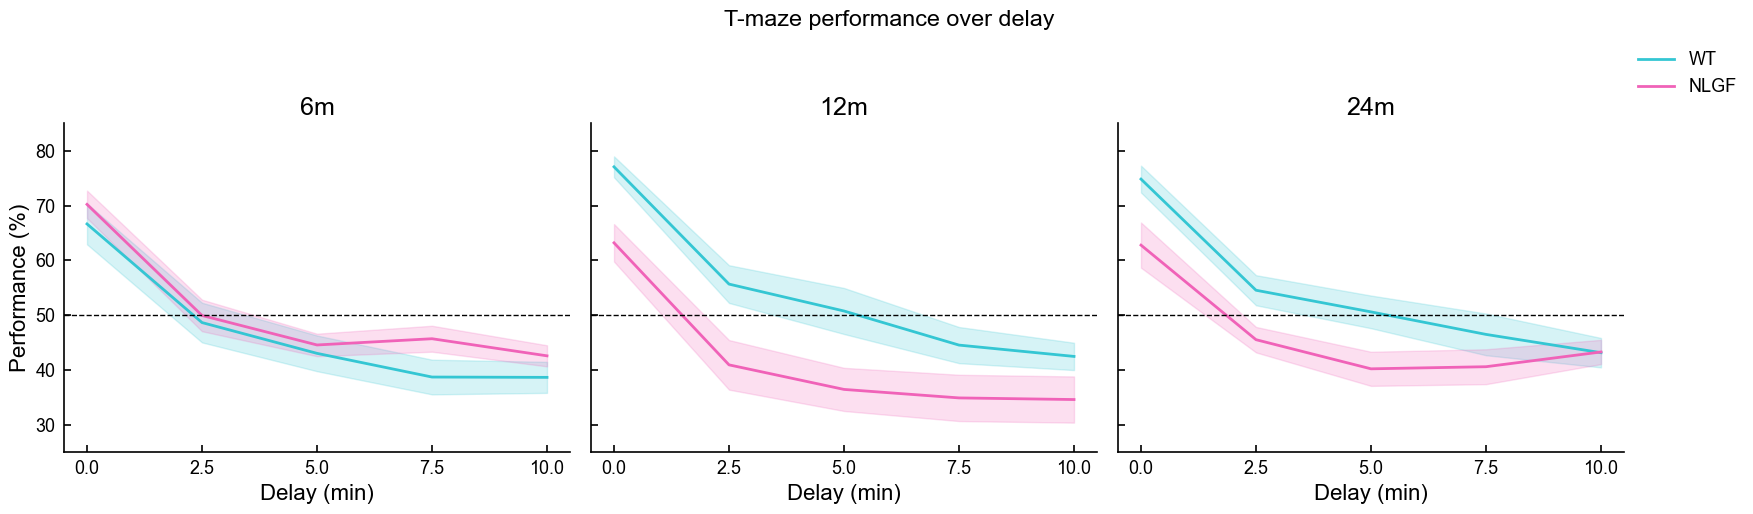


Endpoint genotype statistics: T-maze performance over delay


,Age,Metric,Comparison,Group 1,Group 2,n1,n2,mean1,mean2,test,p,p_adj,stars
0,6m,performance_percent,WT vs NLGF,WT,NLGF,20,15,38.640115,42.569650,Welch t-test,0.259577,0.259577,ns
1,12m,performance_percent,WT vs NLGF,WT,NLGF,10,12,42.463855,34.594030,Welch t-test,0.125893,0.125893,ns
2,24m,performance_percent,WT vs NLGF,WT,NLGF,17,19,43.145635,43.275711,Welch t-test,0.970413,0.970413,ns


,Age,Metric,Comparison,Group 1,Group 2,n1,n2,mean1,mean2,test,p,p_adj,stars,x_value
0,6m,performance_percent,WT vs NLGF,WT,NLGF,20,15,38.640115,42.569650,Welch t-test,0.259577,0.259577,ns,10.0
1,12m,performance_percent,WT vs NLGF,WT,NLGF,10,12,42.463855,34.594030,Welch t-test,0.125893,0.125893,ns,10.0
2,24m,performance_percent,WT vs NLGF,WT,NLGF,17,19,43.145635,43.275711,Welch t-test,0.970413,0.970413,ns,10.0


In [10]:
tmaze_perf_long = melt_wide_timeseries(
    tmaze_performance_df,
    id_cols=["Age", "KageID", "Genotype", "MouseID"],
    value_name="performance_percent",
    x_name="delay_min",
)

display(tmaze_perf_long.head())

plot_line_by_age(
    tmaze_perf_long,
    x="delay_min",
    y="performance_percent",
    ylabel="Performance (%)",
    xlabel="Delay (min)",
    title="T-maze performance over delay",
    ylim=(25, 85),
    xticks=[0, 2.5, 5, 7.5, 10],
    hline=50,
)

## T-maze exponential decay / memory span

This section loads the exponential decay memory-span CSV and plots memory span by age and genotype. 

In [11]:
# Load exponential decay / memory span data
# Put `exponential decay.csv` in the same folder as this notebook or in DATA_DIR.

possible_memory_files = [
    Path("exponential decay.csv"),
    DATA_DIR / "exponential decay.csv",
    Path("'/Volumes/Aimi_SmrtKg/behaviour/exponential decay.csv'"),  # keeps this working in ChatGPT sandbox
]

MEMORY_FILE = None
for p in possible_memory_files:
    if p.exists():
        MEMORY_FILE = p
        break

if MEMORY_FILE is None:
    raise FileNotFoundError(
        "Could not find 'exponential decay.csv'. Put it in the same folder as the notebook "
        "or update MEMORY_FILE to the correct path."
    )

memory_span_df = pd.read_csv(MEMORY_FILE)

memory_span_df = memory_span_df.rename(
    columns={
        "age": "Age",
        "kage": "KageID",
        "group": "Genotype",
        "memory span (min)": "Memory span (min)",
    }
)

memory_span_df["Age"] = memory_span_df["Age"].apply(clean_age)
memory_span_df["Genotype"] = memory_span_df["Genotype"].apply(clean_genotype)
memory_span_df["KageID"] = memory_span_df["KageID"].astype(str).str.strip()
memory_span_df["MouseID"] = memory_span_df["Age"].astype(str) + "_" + memory_span_df["KageID"].astype(str)
memory_span_df["Memory span (min)"] = pd.to_numeric(memory_span_df["Memory span (min)"], errors="coerce")

print("Loaded:", MEMORY_FILE)
display(memory_span_df.head())


Loaded: /Volumes/Aimi_SmrtKg/behaviour/exponential decay.csv


,Age,KageID,Genotype,Memory span (min),MouseID
0,6m,kage1,WT,0.53966,6m_kage1
1,6m,kage2,WT,5.11380,6m_kage2
2,6m,kage7,WT,7.94900,6m_kage7
3,6m,kage8,WT,NaN,6m_kage8
4,6m,kage9,WT,NaN,6m_kage9


/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_26194/1080460182.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_26194/1080460182.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_26194/1080460182.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/g8/st_0_lj16j97jxz803bqsb8c0000gn/T/ipykernel_26194/1080460182.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

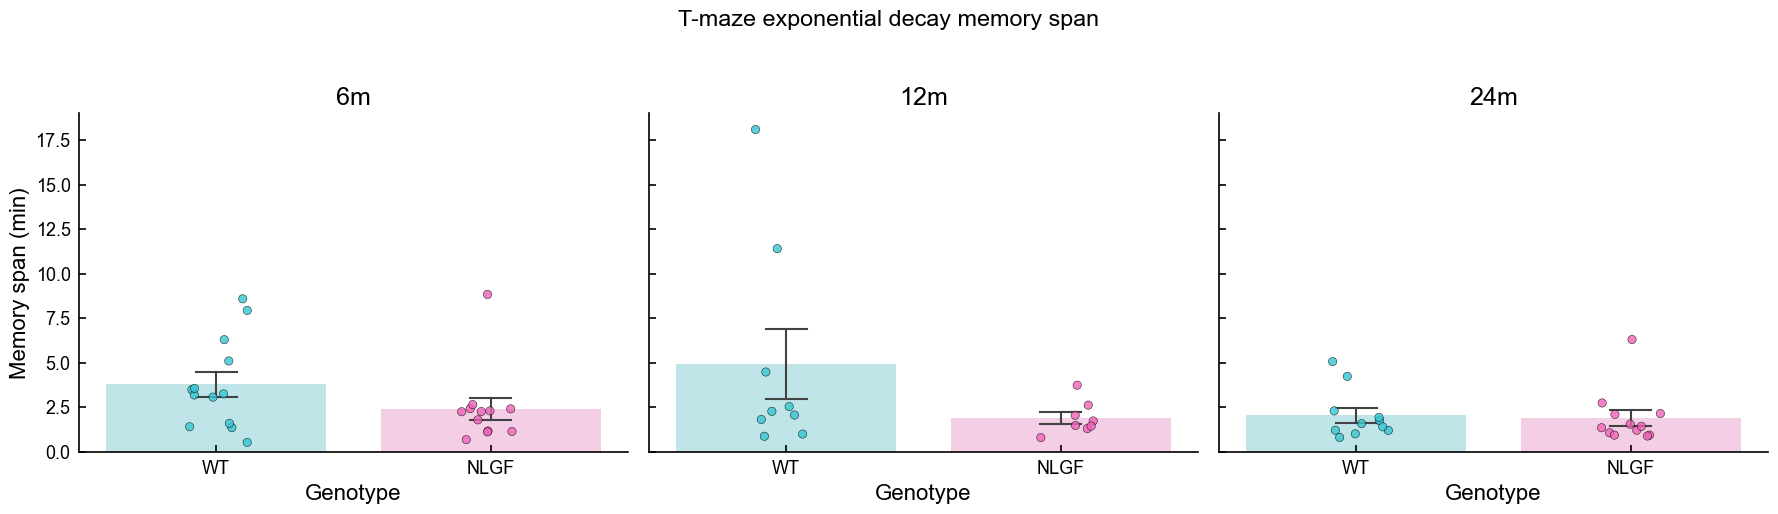

In [12]:
fig, axes = plt.subplots(1, len(AGE_ORDER), figsize=(18, 5), sharey=True)

for ax, age in zip(axes, AGE_ORDER):

    sub = memory_span_df[
        memory_span_df["Age"] == age
    ].copy()

    sns.barplot(
        data=sub,
        x="Genotype",
        y="Memory span (min)",
        order=GENO_ORDER,
        palette=GENO_COLORS,
        estimator=np.mean,
        errorbar=("se", 1),   # SEM
        capsize=0.15,
        err_kws={"linewidth": 1.5},
        alpha=0.35,
        ax=ax,
    )

    sns.stripplot(
        data=sub,
        x="Genotype",
        y="Memory span (min)",
        order=GENO_ORDER,
        palette=GENO_COLORS,
        size=6,
        jitter=0.12,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.4,
        ax=ax,
    )

    format_axes(ax)

    ax.set_title(age)
    ax.set_xlabel("Genotype")
    ax.set_ylabel(
        "Memory span (min)"
        if age == AGE_ORDER[0]
        else ""
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.suptitle(
    "T-maze exponential decay memory span",
    y=1.03,
)

plt.tight_layout()
plt.show()

# Average daily velocity

Velocity is stored as a 24-hour profile with 20-minute bins. The x-axis is time of day in hours.

,Age,KageID,Genotype,MouseID,time_h,velocity
0,6m,kage1,WT,6m_kage1,0.0,0.984704
1,6m,kage2,WT,6m_kage2,0.0,1.077985
2,6m,kage7,WT,6m_kage7,0.0,1.355589
3,6m,kage8,WT,6m_kage8,0.0,1.288765
4,6m,kage9,WT,6m_kage9,0.0,1.411769


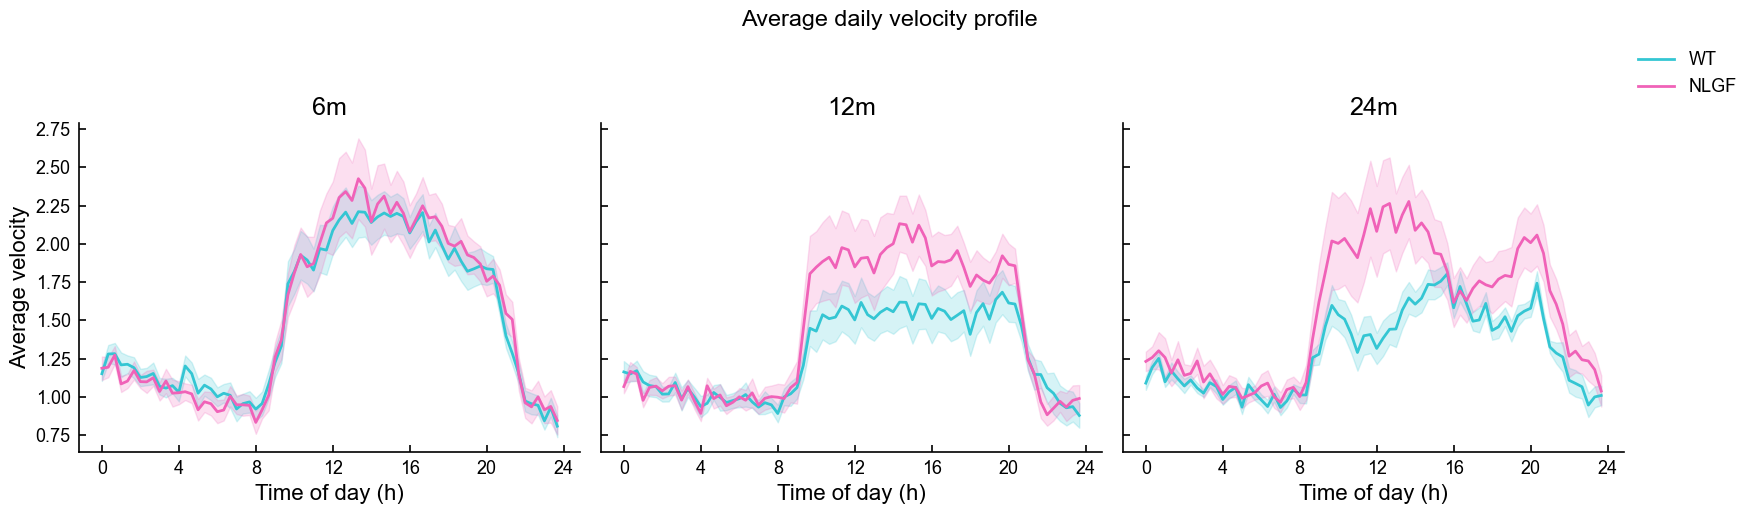


Endpoint genotype statistics: Average daily velocity profile


,Age,Metric,Comparison,Group 1,Group 2,n1,n2,mean1,mean2,test,p,p_adj,stars
0,6m,velocity,WT vs NLGF,WT,NLGF,20,15,0.809155,0.846378,Welch t-test,0.750971,0.750971,ns
1,12m,velocity,WT vs NLGF,WT,NLGF,10,12,0.879352,0.990025,Welch t-test,0.363451,0.363451,ns
2,24m,velocity,WT vs NLGF,WT,NLGF,16,18,1.009836,1.038850,Welch t-test,0.810654,0.810654,ns


,Age,Metric,Comparison,Group 1,Group 2,n1,n2,mean1,mean2,test,p,p_adj,stars,x_value
0,6m,velocity,WT vs NLGF,WT,NLGF,20,15,0.809155,0.846378,Welch t-test,0.750971,0.750971,ns,23.67
1,12m,velocity,WT vs NLGF,WT,NLGF,10,12,0.879352,0.990025,Welch t-test,0.363451,0.363451,ns,23.67
2,24m,velocity,WT vs NLGF,WT,NLGF,16,18,1.009836,1.038850,Welch t-test,0.810654,0.810654,ns,23.67


In [24]:
velocity_long = melt_wide_timeseries(
    velocity_df,
    id_cols=["Age", "KageID", "Genotype", "MouseID"],
    value_name="velocity",
    x_name="time_h",
)

display(velocity_long.head())

plot_line_by_age(
    velocity_long,
    x="time_h",
    y="velocity",
    ylabel="Average velocity",
    xlabel="Time of day (h)",
    title="Average daily velocity profile",
    xticks=[0, 4, 8, 12, 16, 20, 24],
)

In [14]:
def plot_bar_metric_by_age(
    df,
    metric,
    ylabel,
    title,
    show_stats=True,
):
    plot_df = df.copy()

    plot_df[metric] = pd.to_numeric(
        plot_df[metric],
        errors="coerce"
    )

    plot_df = plot_df.dropna(
        subset=["Age", "Genotype", metric]
    )
    plot_df = plot_df[plot_df["Genotype"].isin(GENO_ORDER)]

    fig, axes = plt.subplots(
        1,
        len(AGE_ORDER),
        figsize=(18, 5),
        sharey=True
    )

    all_stats = []

    for ax, age in zip(axes, AGE_ORDER):

        sub = plot_df[
            plot_df["Age"] == age
        ].copy()

        sns.barplot(
            data=sub,
            x="Genotype",
            y=metric,
            order=GENO_ORDER,
            hue="Genotype",
            hue_order=GENO_ORDER,
            palette=GENO_COLORS,
            errorbar="se",
            capsize=0.15,
            err_kws={"linewidth": 1.5},
            alpha=0.35,
            legend=False,
            ax=ax
        )

        sns.stripplot(
            data=sub,
            x="Genotype",
            y=metric,
            order=GENO_ORDER,
            hue="Genotype",
            hue_order=GENO_ORDER,
            palette=GENO_COLORS,
            jitter=0.15,
            dodge=False,
            size=5,
            alpha=0.8,
            edgecolor="black",
            linewidth=0.25,
            legend=False,
            ax=ax
        )

        stats_df = pairwise_genotype_stats(sub, metric, age=age)
        if not stats_df.empty:
            all_stats.append(stats_df)

        format_axes(ax)

        ax.set_title(age)
        ax.set_xlabel("Genotype")
        ax.set_ylabel(ylabel if age == AGE_ORDER[0] else "")
        ax.tick_params(axis="x", rotation=30)

        ymin, ymax = ax.get_ylim()
        yrange = ymax - ymin if ymax > ymin else 1
        y_base = ymax + yrange * 0.05
        y_step = yrange * 0.08
        add_genotype_stars(ax, stats_df, y_base, y_step)
        ax.set_ylim(ymin, y_base + y_step * 4)

    fig.suptitle(title, y=1.03)

    plt.tight_layout()
    plt.show()

    if show_stats:
        if len(all_stats):
            stats_out = pd.concat(all_stats, ignore_index=True)
        else:
            stats_out = pd.DataFrame()
        display_stats_table(f"Pairwise genotype statistics: {title}", stats_out)
        return stats_out


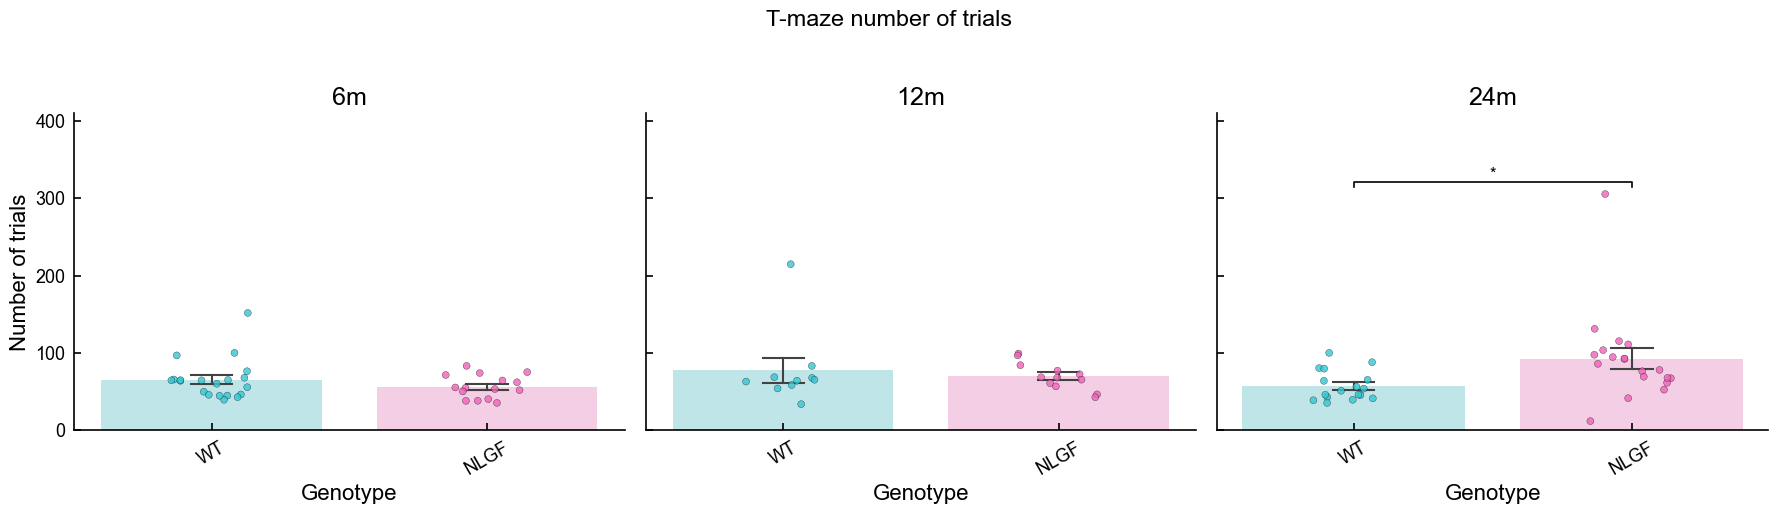


Pairwise genotype statistics: T-maze number of trials


,Age,Metric,Comparison,Group 1,Group 2,n1,n2,mean1,mean2,test,p,p_adj,stars
0,6m,n trials,WT vs NLGF,WT,NLGF,20,15,65.717050,56.682533,Welch t-test,0.206468,0.206468,ns
1,12m,n trials,WT vs NLGF,WT,NLGF,10,12,77.472900,70.041333,Welch t-test,0.662926,0.662926,ns
2,24m,n trials,WT vs NLGF,WT,NLGF,17,19,57.430941,92.585421,Welch t-test,0.021771,0.021771,*


,Age,Metric,Comparison,Group 1,Group 2,n1,n2,mean1,mean2,test,p,p_adj,stars
0,6m,n trials,WT vs NLGF,WT,NLGF,20,15,65.717050,56.682533,Welch t-test,0.206468,0.206468,ns
1,12m,n trials,WT vs NLGF,WT,NLGF,10,12,77.472900,70.041333,Welch t-test,0.662926,0.662926,ns
2,24m,n trials,WT vs NLGF,WT,NLGF,17,19,57.430941,92.585421,Welch t-test,0.021771,0.021771,*


In [15]:
plot_bar_metric_by_age(
    tmaze_trials_df,
    metric="n trials",
    ylabel="Number of trials",
    title="T-maze number of trials",
)

# Save cleaned master tables

In [ ]:
OUTPUT_DIR = DATA_DIR / "smartkage_uploaded_master_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

velocity_df.to_csv(OUTPUT_DIR / "velocity_cleaned_master.csv", index=False)
tmaze_trials_df.to_csv(OUTPUT_DIR / "tmaze_trials_cleaned_master.csv", index=False)
tmaze_side_bias_df.to_csv(OUTPUT_DIR / "tmaze_side_bias_cleaned_master.csv", index=False)
tmaze_performance_df.to_csv(OUTPUT_DIR / "tmaze_performance_cleaned_master.csv", index=False)
nor_exploration_df.to_csv(OUTPUT_DIR / "nor_exploration_cleaned_master.csv", index=False)
nor_lr_bias_df.to_csv(OUTPUT_DIR / "nor_lr_bias_cleaned_master.csv", index=False)
nor_di_df.to_csv(OUTPUT_DIR / "nor_di_cleaned_master.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR)